In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Duolingo Learner Engagement Analysis

## Analyzing Learner Behavior, Engagement & Inactivity Using Python

### Project Overview

This project analyzes learner engagement patterns using a dataset of 6,000 learners.

The analysis focuses on learner activity, learning behavior, subscription status, platform usage, inactivity, and learner segmentation to identify meaningful patterns and generate business recommendations.

### Business Objective

The main objective is to understand:

- What behaviors are associated with higher learner engagement?
- How does engagement differ between Free and Super subscribers?
- How does learner behavior vary across platforms and countries?
- Which learner groups may require re-engagement?
- What actionable insights can be derived from learner behavior?

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Import Libraries and Load Dataset

The dataset is loaded into a Pandas DataFrame for analysis. Python libraries are used for data manipulation, numerical analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("duolingo_learners_engagement_analysis.xlsx")

In [4]:
df.head()

,learner_id,signup_date,country,platform,courses_active,subscription,days_active_last_30,sessions_per_week,avg_session_minutes,longest_streak_days,lessons_completed_90d,xp_earned_90d,share_sessions_weekend,share_sessions_morning,leaderboard_weeks_joined,share_lessons_new_content,days_since_last_active,notifications_enabled
0,L100001,2025-06-13,United States,android,1,super,16,3.1,NaN,30,862,13039,0.39,0.66,7,0.16,0,yes
1,L100002,2024-07-13,India,android,2,free,11,1.3,7.9,29,236,4151,0.42,0.19,0,0.72,16,yes
2,L100003,2025-04-14,Mexico,android,2,free,14,4.4,111.7,7,152,2647,0.66,0.00,0,0.66,8,no
3,L100004,2024-01-22,Brazil,ios,1,super,30,8.7,23.4,133,548,11093,0.63,0.43,13,0.48,0,yes
4,L100005,2024-01-22,India,ios,1,free,6,6.6,87.0,3,86,1390,0.87,0.14,0,0.74,0,yes


## 2. Initial Data Inspection


In [5]:
df.shape

(6000, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   learner_id                 6000 non-null   object        
 1   signup_date                6000 non-null   datetime64[ns]
 2   country                    6000 non-null   object        
 3   platform                   6000 non-null   object        
 4   courses_active             6000 non-null   int64         
 5   subscription               6000 non-null   object        
 6   days_active_last_30        6000 non-null   int64         
 7   sessions_per_week          6000 non-null   float64       
 8   avg_session_minutes        5907 non-null   float64       
 9   longest_streak_days        6000 non-null   int64         
 10  lessons_completed_90d      6000 non-null   int64         
 11  xp_earned_90d              6000 non-null   int64         
 12  share_

In [7]:
df.columns

Index(['learner_id', 'signup_date', 'country', 'platform', 'courses_active',
       'subscription', 'days_active_last_30', 'sessions_per_week',
       'avg_session_minutes', 'longest_streak_days', 'lessons_completed_90d',
       'xp_earned_90d', 'share_sessions_weekend', 'share_sessions_morning',
       'leaderboard_weeks_joined', 'share_lessons_new_content',
       'days_since_last_active', 'notifications_enabled'],
      dtype='object')

## 3. Data Quality Assessment

In [8]:
df.isnull().sum()

learner_id                    0
signup_date                   0
country                       0
platform                      0
courses_active                0
subscription                  0
days_active_last_30           0
sessions_per_week             0
avg_session_minutes          93
longest_streak_days           0
lessons_completed_90d         0
xp_earned_90d                 0
share_sessions_weekend        0
share_sessions_morning        0
leaderboard_weeks_joined      0
share_lessons_new_content     0
days_since_last_active        0
notifications_enabled         0
dtype: int64

In [8]:
(df.isnull().sum() / len(df) *100).sort_values(ascending = False)

avg_session_minutes          1.55
learner_id                   0.00
lessons_completed_90d        0.00
days_since_last_active       0.00
share_lessons_new_content    0.00
leaderboard_weeks_joined     0.00
share_sessions_morning       0.00
share_sessions_weekend       0.00
xp_earned_90d                0.00
longest_streak_days          0.00
signup_date                  0.00
sessions_per_week            0.00
days_active_last_30          0.00
subscription                 0.00
courses_active               0.00
platform                     0.00
country                      0.00
notifications_enabled        0.00
dtype: float64

In [9]:
df.duplicated().sum()

0

In [10]:
df["learner_id"].duplicated().sum()

0

## 4. Exploratory Data Analysis (EDA)

## 4.1. Categorical Analysis

In [11]:
df.nunique().sort_values()

notifications_enabled           2
subscription                    2
platform                        3
courses_active                  3
country                         8
leaderboard_weeks_joined       14
days_active_last_30            31
share_lessons_new_content     101
share_sessions_weekend        101
share_sessions_morning        101
days_since_last_active        141
sessions_per_week             485
longest_streak_days           708
signup_date                   898
avg_session_minutes          1006
lessons_completed_90d        1218
xp_earned_90d                4476
learner_id                   6000
dtype: int64

In [12]:
df["country"].value_counts()

country
United States     1777
India             1064
Brazil             724
Mexico             615
France             515
Germany            497
Japan              414
United Kingdom     394
Name: count, dtype: int64

In [13]:
df["platform"].value_counts()

platform
android    3163
ios        2226
web         611
Name: count, dtype: int64

In [14]:
df["subscription"].value_counts()

subscription
free     4947
super    1053
Name: count, dtype: int64

In [15]:
df["notifications_enabled"].value_counts()

notifications_enabled
yes    3836
no     2164
Name: count, dtype: int64

In [16]:
df["leaderboard_weeks_joined"].value_counts()

leaderboard_weeks_joined
0     2153
1      536
2      499
3      477
4      406
5      383
6      309
13     281
7      240
8      203
9      171
10     145
11     102
12      95
Name: count, dtype: int64

## 4.2. Descriptive Analysis

In [17]:
#Descriptive Statistics
df.describe()

,signup_date,courses_active,days_active_last_30,sessions_per_week,avg_session_minutes,longest_streak_days,lessons_completed_90d,xp_earned_90d,share_sessions_weekend,share_sessions_morning,leaderboard_weeks_joined,share_lessons_new_content,days_since_last_active
count,6000,6000.000000,6000.000000,6000.000000,5907.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2024-03-26 18:20:52.800000,1.364833,13.965500,8.178433,24.464314,109.710333,347.376167,6282.677500,0.412318,0.431190,3.427667,0.626945,11.061333
min,2023-01-01 00:00:00,1.000000,0.000000,0.100000,1.000000,1.000000,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-08-18 18:00:00,1.000000,4.000000,1.500000,4.900000,4.000000,42.000000,1191.750000,0.210000,0.250000,0.000000,0.470000,0.000000
50%,2024-03-29 12:00:00,1.000000,13.000000,3.700000,11.200000,14.000000,146.000000,3025.000000,0.380000,0.430000,2.000000,0.630000,4.000000
75%,2024-11-05 06:00:00,2.000000,24.000000,9.200000,29.800000,127.250000,370.000000,6695.500000,0.580000,0.610000,6.000000,0.790000,12.000000
max,2025-06-19 00:00:00,3.000000,30.000000,232.700000,564.000000,3169.000000,10151.000000,150369.000000,1.000000,1.000000,13.000000,1.000000,535.000000
std,NaN,0.608653,10.697323,15.473377,36.460688,212.394659,687.205560,11686.832435,0.261674,0.248044,3.876331,0.218513,20.773047


In [18]:
df["sessions_per_week"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    6000.000000
mean        8.178433
std        15.473377
min         0.100000
25%         1.500000
50%         3.700000
75%         9.200000
90%        18.110000
95%        27.905000
99%        65.704000
max       232.700000
Name: sessions_per_week, dtype: float64

In [19]:
df["avg_session_minutes"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    5907.000000
mean       24.464314
std        36.460688
min         1.000000
25%         4.900000
50%        11.200000
75%        29.800000
90%        60.300000
95%        86.500000
99%       173.376000
max       564.000000
Name: avg_session_minutes, dtype: float64

In [20]:
df["longest_streak_days"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    6000.000000
mean      109.710333
std       212.394659
min         1.000000
25%         4.000000
50%        14.000000
75%       127.250000
90%       323.100000
95%       520.000000
99%       989.020000
max      3169.000000
Name: longest_streak_days, dtype: float64

In [21]:
df["lessons_completed_90d"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count     6000.000000
mean       347.376167
std        687.205560
min          1.000000
25%         42.000000
50%        146.000000
75%        370.000000
90%        791.100000
95%       1296.100000
99%       3129.180000
max      10151.000000
Name: lessons_completed_90d, dtype: float64

## 4.3 Group Analysis

In [60]:
# Note: Before run this cell, run the Feature Engineering cell and then run other analysis cells.
#Comapring Free vs Super Learners
#How do engagement patterns differ between Free and Super learners?

subscription_analysis = df_analysis.groupby("subscription").agg(
    learners=("learner_id", "count"),
    avg_engagement=("user_engagement_score", "mean"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean"),
    avg_xp=("xp_earned_90d", "mean"),
    avg_streak=("longest_streak_days", "mean")
).round(2)
subscription_analysis

,learners,avg_engagement,avg_days_active,avg_sessions,avg_lessons,avg_xp,avg_streak
subscription,,,,,,,
free,4947,84.99,12.77,7.40,299.58,5484.42,95.62
super,1053,150.84,19.60,11.85,571.91,10032.92,175.90


In [61]:
#platform analysis
#Which platform associates with the user engagement?
platform_analysis = df_analysis.groupby("platform").agg(
    learners=("learner_id", "count"),
    avg_engagement=("user_engagement_score", "mean"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean"),
    avg_xp=("xp_earned_90d", "mean")
).round(2)

platform_analysis

,learners,avg_engagement,avg_days_active,avg_sessions,avg_lessons,avg_xp
platform,,,,,,
android,3163,96.77,13.98,8.33,347.64,6287.42
ios,2226,95.75,14.04,8.05,343.20,6222.45
web,611,98.33,13.61,7.90,361.22,6477.56


In [62]:
#Country Analysis
#Are there meaningful differences in learner engagement across markets?

country_analysis = df_analysis.groupby("country").agg(
    learners=("learner_id", "count"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean"),
    avg_xp=("xp_earned_90d", "mean"),
    avg_streak=("longest_streak_days", "mean")
).round(2)

country_analysis.sort_values("avg_xp", ascending=False)

,learners,avg_days_active,avg_sessions,avg_lessons,avg_xp,avg_streak
country,,,,,,
Germany,497,14.60,8.12,404.38,6997.96,98.66
France,515,13.12,8.14,381.30,6971.70,103.28
Mexico,615,13.53,8.91,378.31,6886.67,106.01
United States,1777,13.92,7.83,350.29,6316.66,110.39
India,1064,14.12,8.33,332.08,6120.57,117.40
Japan,414,14.92,9.58,329.73,6016.31,112.93
United Kingdom,394,14.09,7.53,324.91,5774.53,109.72
Brazil,724,13.76,7.80,295.49,5372.16,110.19


In [63]:
#correlation analysis
#Which learner behaviors are most strongly associated with our engagement score?"
df_analysis[[
    "days_active_last_30",
    "sessions_per_week",
    "avg_session_minutes",
    "longest_streak_days",
    "lessons_completed_90d",
    "xp_earned_90d",
    "days_since_last_active",
    "user_engagement_score"
]].corr()["user_engagement_score"].sort_values(ascending=False).round(2)

user_engagement_score     1.00
xp_earned_90d             0.99
lessons_completed_90d     0.97
sessions_per_week         0.69
days_active_last_30       0.33
longest_streak_days       0.13
avg_session_minutes      -0.01
days_since_last_active   -0.11
Name: user_engagement_score, dtype: float64

In [64]:
#calculating the correlation
correlation = df_analysis[
    ["days_active_last_30", "lessons_completed_90d"]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.2f}")

Correlation: 0.25


## 5. Data Cleaning

In [65]:
#create a clean copy of the dataset
df_clean = df.copy()

#convert signup_date to datatime
df_clean["signup_date"] = pd.to_datetime(df_clean["signup_date"])

#Fill missing avg_session_minutes with the median
median_session_time = df_clean["avg_session_minutes"].median()

df_clean["avg_session_minutes"] = df_clean["avg_session_minutes"].fillna(median_session_time)

#check the result for filled median values on missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("\nMedian used for avg_session_minutes:",median_session_time)
print("\nDataset shape: ",df_clean.shape)

Missing values after cleaning:
0

Median used for avg_session_minutes: 11.2

Dataset shape:  (6000, 18)


In [66]:
df[df["avg_session_minutes"].isnull()][
["days_active_last_30","sessions_per_week","lessons_completed_90d","xp_earned_90d"]].describe()

,days_active_last_30,sessions_per_week,lessons_completed_90d,xp_earned_90d
count,93.000000,93.000000,93.000000,93.000000
mean,15.623656,8.317204,339.021505,6154.451613
std,10.594209,9.858759,442.359926,6960.919588
min,0.000000,0.200000,3.000000,141.000000
25%,5.000000,2.000000,62.000000,1263.000000
50%,16.000000,4.800000,163.000000,3255.000000
75%,25.000000,10.900000,493.000000,8884.000000
max,30.000000,46.200000,2809.000000,40424.000000


In [67]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   learner_id                 6000 non-null   object        
 1   signup_date                6000 non-null   datetime64[ns]
 2   country                    6000 non-null   object        
 3   platform                   6000 non-null   object        
 4   courses_active             6000 non-null   int64         
 5   subscription               6000 non-null   object        
 6   days_active_last_30        6000 non-null   int64         
 7   sessions_per_week          6000 non-null   float64       
 8   avg_session_minutes        6000 non-null   float64       
 9   longest_streak_days        6000 non-null   int64         
 10  lessons_completed_90d      6000 non-null   int64         
 11  xp_earned_90d              6000 non-null   int64         
 12  share_

## 6. Feature Engineering

In [58]:
#create a clean copy of analysis
df_analysis = df_clean.copy()

#overall engagement score (combining several engagement behsviors into one analytical measure)
df_analysis["user_engagement_score"] = (
    df_analysis["days_active_last_30"]+
    df_analysis["sessions_per_week"]+
    df_analysis["lessons_completed_90d"]/30+
    df_analysis["xp_earned_90d"]/100
).round(2)   

#Inactivity category (this will make days_since_last_active easier to analyze and visualize)
df_analysis["inactivity_level"] = pd.cut(
    df_analysis["days_since_last_active"],
    bins=[-1,7,30,90,float("inf")],
    labels=["Recently Active","Moderately Inactive","Highly Inactive","Long-Term Inactive"]
)

#session intensity (combines session frequency and session duration)
df_analysis["session_intensity"] = (
    df_analysis["sessions_per_week"]*df_analysis["avg_session_minutes"]
).round(2)

print(df_analysis[["user_engagement_score","inactivity_level","session_intensity"]].head())
    

   user_engagement_score     inactivity_level  session_intensity
0                 178.22      Recently Active              34.72
1                  61.68  Moderately Inactive              10.27
2                  49.94  Moderately Inactive             491.48
3                 167.90      Recently Active             203.58
4                  29.37      Recently Active             574.20


## 7. Learner Engagement and Inactivity Analysis

In [68]:
#Understanding the learner engagement by inactivity level
#How does learner engegement differ as learners become more inactive?
df_analysis.groupby("inactivity_level", observed=True).agg(
    learners=("learner_id", "count"),
    avg_engagement=("user_engagement_score", "mean"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean")
).round(2)

,learners,avg_engagement,avg_days_active,avg_sessions,avg_lessons
inactivity_level,,,,,
Recently Active,3951,119.38,18.06,10.56,426.72
Moderately Inactive,1454,47.21,6.40,3.60,167.23
Highly Inactive,517,62.74,5.39,3.24,253.46
Long-Term Inactive,78,83.95,4.45,5.32,309.06


## 8. Data Visualization

In [69]:
country_counts = (
    df_analysis["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "learners"]

country_counts

,country,learners
0,United States,1777
1,India,1064
2,Brazil,724
3,Mexico,615
4,France,515
5,Germany,497
6,Japan,414
7,United Kingdom,394


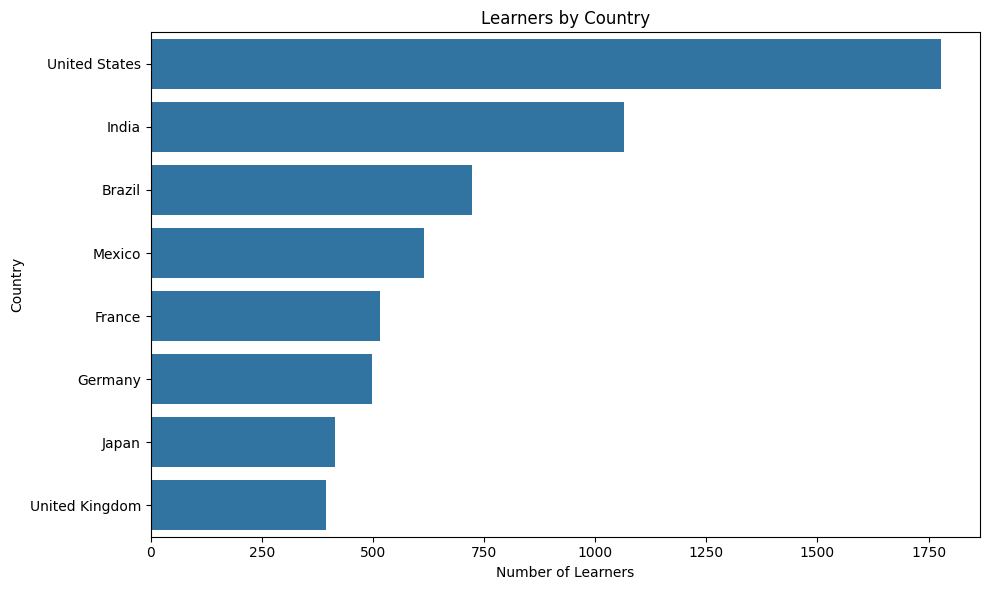

In [70]:
#Where are the learners concentrated geographically
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_counts,
    x="learners",
    y="country"
)

plt.title("Learners by Country")
plt.xlabel("Number of Learners")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [71]:
country_xp = (
    df_analysis.groupby("country")["xp_earned_90d"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

country_xp.columns = ["country", "avg_xp"]

country_xp

,country,avg_xp
0,Germany,6997.959759
1,France,6971.702913
2,Mexico,6886.669919
3,United States,6316.661790
4,India,6120.565789
5,Japan,6016.309179
6,United Kingdom,5774.525381
7,Brazil,5372.161602


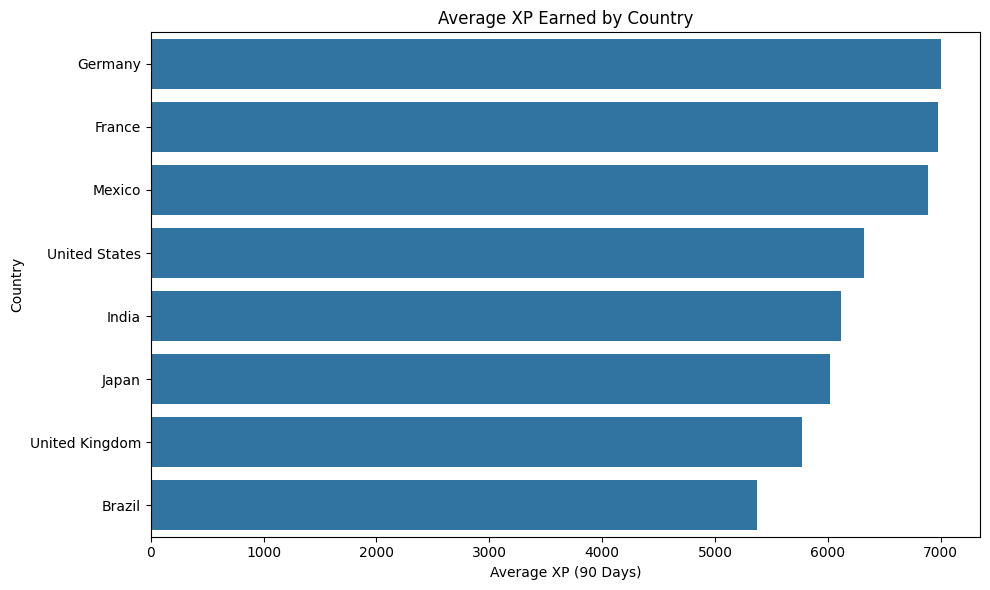

In [72]:
#How much XP are learners earning on average?

plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_xp,
    x="avg_xp",
    y="country"
)

plt.title("Average XP Earned by Country")
plt.xlabel("Average XP (90 Days)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [73]:
#create comparison table

subscription_analysis = df_analysis.groupby("subscription").agg(
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean"),
    avg_xp=("xp_earned_90d", "mean")
).round(2)

subscription_analysis

,avg_days_active,avg_sessions,avg_lessons,avg_xp
subscription,,,,
free,12.77,7.40,299.58,5484.42
super,19.60,11.85,571.91,10032.92


In [74]:
#Calculate Super vs Free percentage difference
free = subscription_analysis.loc["free"]
super_ = subscription_analysis.loc["super"]

comparison = ((super_ - free) / free * 100).round(1)

comparison

avg_days_active    53.5
avg_sessions       60.1
avg_lessons        90.9
avg_xp             82.9
dtype: float64

In [75]:
comparison_df = comparison.reset_index()

comparison_df.columns = ["metric", "super_vs_free_pct"]

comparison_df

,metric,super_vs_free_pct
0,avg_days_active,53.5
1,avg_sessions,60.1
2,avg_lessons,90.9
3,avg_xp,82.9


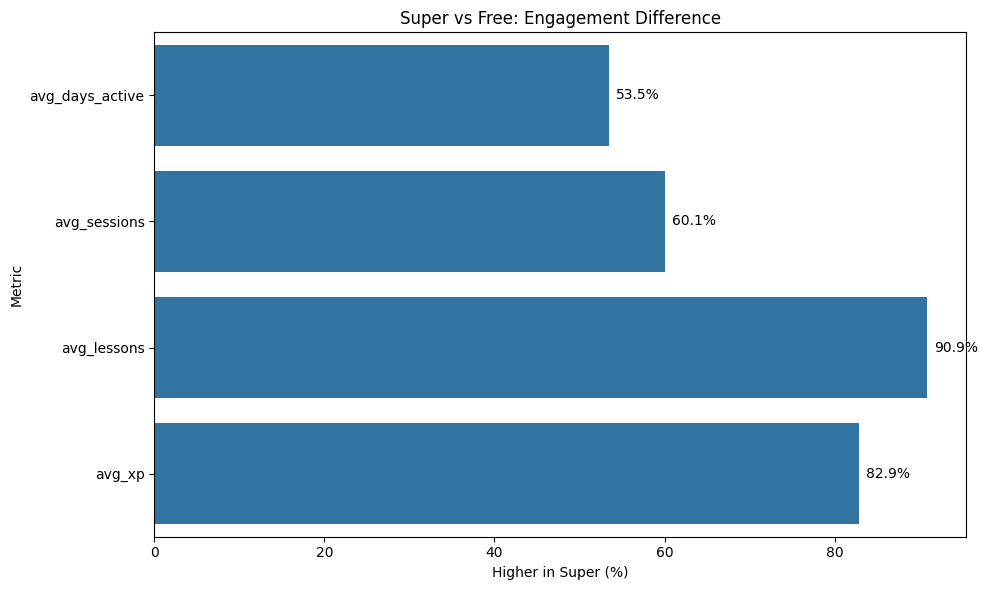

In [76]:
#subscription engagement comparison
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=comparison_df,
    x="super_vs_free_pct",
    y="metric"
)

# Add percentage labels to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5
    )

plt.title("Super vs Free: Engagement Difference")
plt.xlabel("Higher in Super (%)")
plt.ylabel("Metric")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

In [77]:
#Inactivity and Engagement

inactivity_chart = df_analysis.groupby(
    "inactivity_level",
    observed=True
).agg(
    learners=("learner_id", "count"),
    avg_engagement=("user_engagement_score", "mean")
).reset_index()

inactivity_chart

,inactivity_level,learners,avg_engagement
0,Recently Active,3951,119.382275
1,Moderately Inactive,1454,47.205076
2,Highly Inactive,517,62.738723
3,Long-Term Inactive,78,83.948205


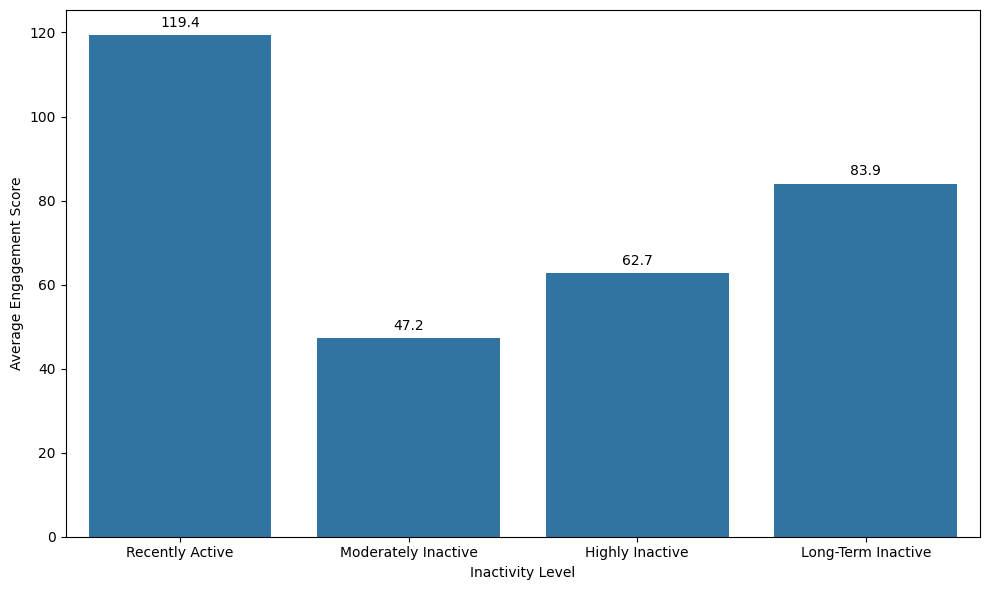

In [78]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=inactivity_chart,
    x="inactivity_level",
    y="avg_engagement"
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4
    )


plt.xlabel("Inactivity Level")
plt.ylabel("Average Engagement Score")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [79]:
#learners who use the platform more frequently also tend to earn more XP
scatter_data = df_analysis[
    ["sessions_per_week", "xp_earned_90d"]
].dropna()

# Keep observations up to the 99th percentile for visualization only
session_limit = scatter_data["sessions_per_week"].quantile(0.99)

scatter_plot = scatter_data[
    scatter_data["sessions_per_week"] <= session_limit
]

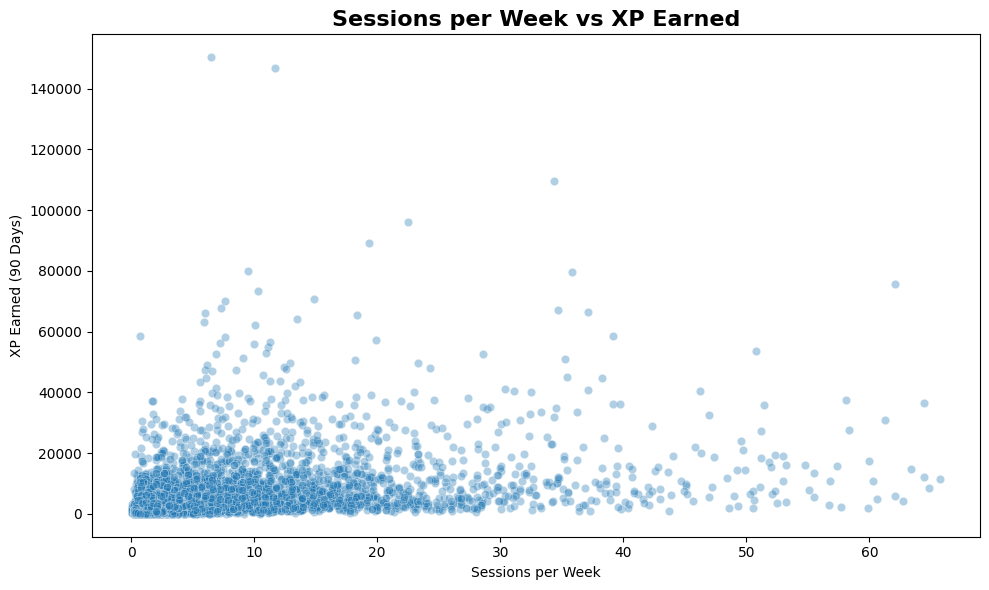

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_plot,
    x="sessions_per_week",
    y="xp_earned_90d",
    alpha=0.35
)

plt.title(
    "Sessions per Week vs XP Earned",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sessions per Week")
plt.ylabel("XP Earned (90 Days)")

plt.tight_layout()
plt.show()

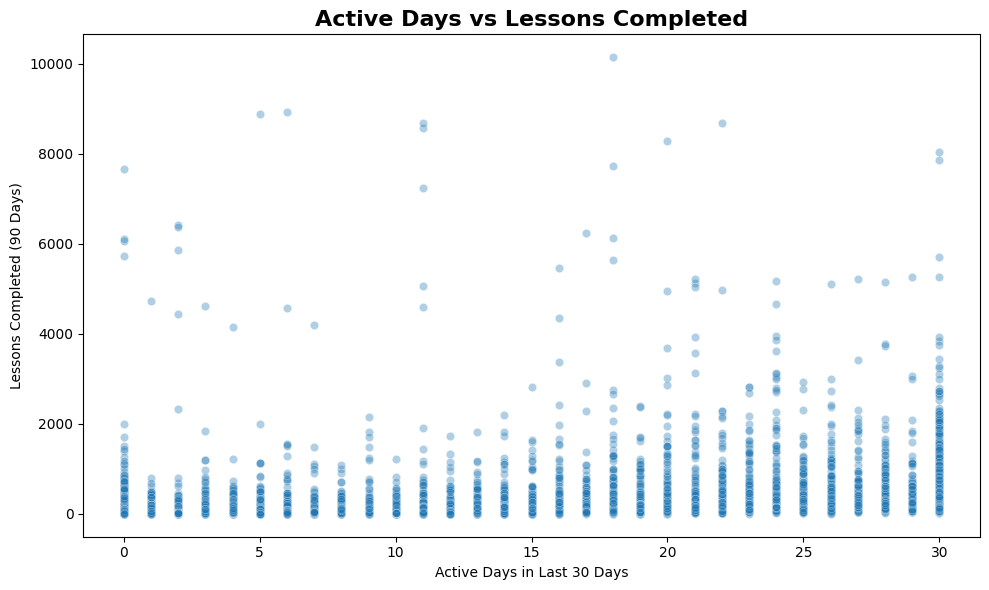

In [80]:
#learners who are active on more days tend to complete more lessons
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_analysis,
    x="days_active_last_30",
    y="lessons_completed_90d",
    alpha=0.35
)

plt.title(
    "Active Days vs Lessons Completed",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Active Days in Last 30 Days")
plt.ylabel("Lessons Completed (90 Days)")

plt.tight_layout()
plt.show()

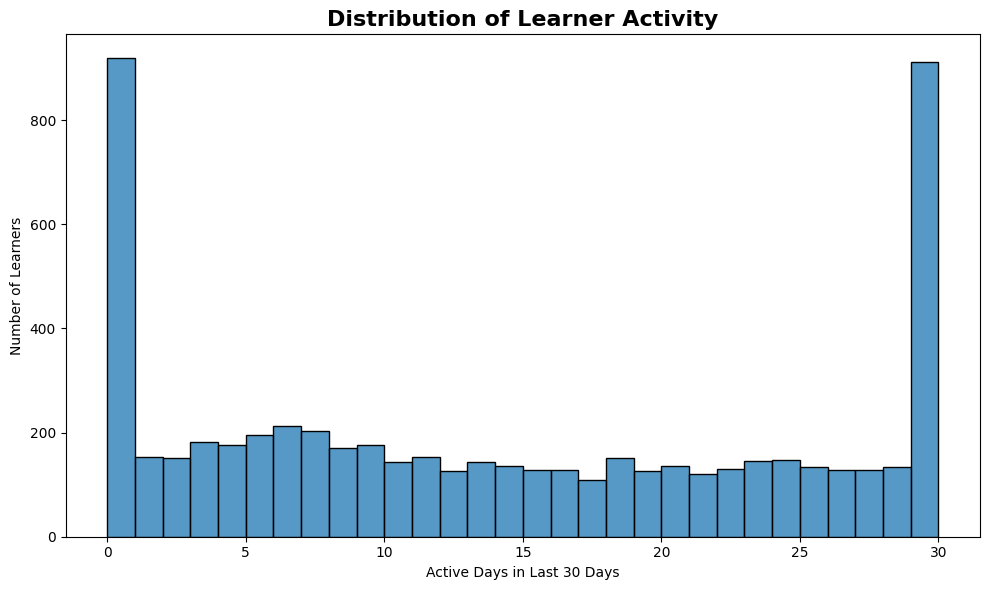

In [44]:
#Learner activity distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_analysis,
    x="days_active_last_30",
    bins=30
)

plt.title(
    "Distribution of Learner Activity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Active Days in Last 30 Days")
plt.ylabel("Number of Learners")

plt.tight_layout()
plt.show()

In [81]:
#Subscription × Platform
subscription_platform = df_analysis.groupby(
    ["platform", "subscription"]
).agg(
    learners=("learner_id", "count"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean")
).reset_index()

subscription_platform

,platform,subscription,learners,avg_days_active,avg_sessions,avg_lessons
0,android,free,2599,12.791458,7.487033,300.056945
1,android,super,564,19.464539,12.188475,566.927305
2,ios,free,1825,12.795616,7.294356,293.073425
3,ios,super,401,19.705736,11.464339,571.319202
4,web,free,523,12.533461,7.313384,319.933078
5,web,super,88,20.011364,11.400000,606.579545


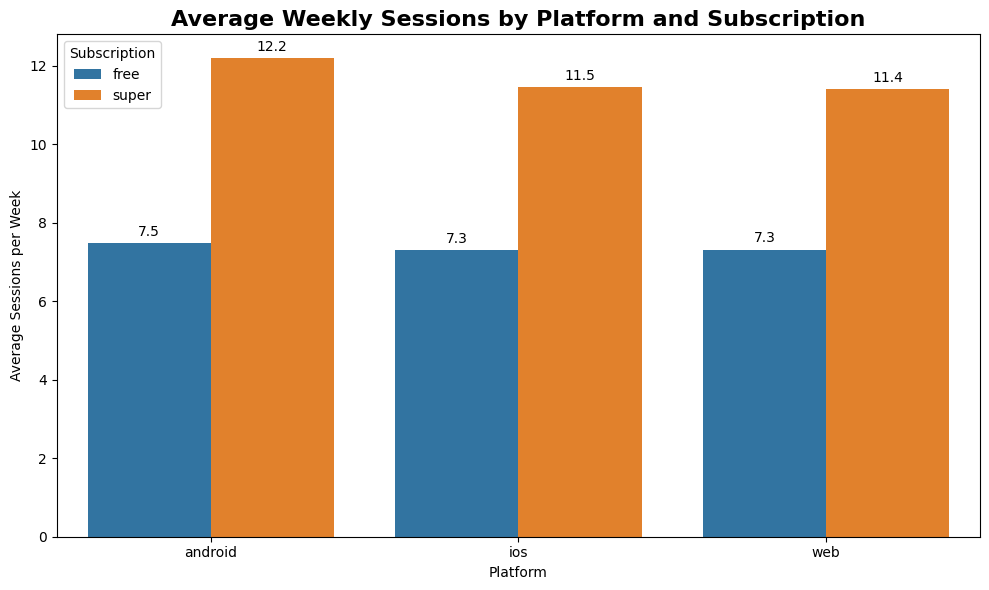

In [82]:
#Does the higher engagement observed among Super learners appear across different platforms?

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=subscription_platform,
    x="platform",
    y="avg_sessions",
    hue="subscription"
)

plt.title(
    "Average Weekly Sessions by Platform and Subscription",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Platform")
plt.ylabel("Average Sessions per Week")
plt.legend(title="Subscription")

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.tight_layout()
plt.show()

## 8. Learner Segmentation

In [83]:
#Learners segmenting
df_analysis["learner_segment"] = np.select(
    [
        (df_analysis["days_active_last_30"] >= 15) &
        (df_analysis["sessions_per_week"] >= 8) &
        (df_analysis["days_since_last_active"] <= 7),

        (df_analysis["days_active_last_30"] >= 8) &
        (df_analysis["sessions_per_week"] >= 4) &
        (df_analysis["days_since_last_active"] <= 30),

        (df_analysis["days_since_last_active"] > 30),

    ],
    [
        "Highly Engaged",
        "Regularly Engaged",
        "At Risk / Inactive"
    ],
    default="Occasionally Engaged"
)

In [84]:
#how many learners fall into each segment
segment_counts = (
    df_analysis["learner_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["segment", "learners"]

segment_counts["percentage"] = (
    segment_counts["learners"] /
    len(df_analysis) * 100
).round(1)

segment_counts

,segment,learners,percentage
0,Occasionally Engaged,2972,49.5
1,Highly Engaged,1444,24.1
2,Regularly Engaged,989,16.5
3,At Risk / Inactive,595,9.9


In [85]:
segment_profile = df_analysis.groupby(
    "learner_segment"
).agg(
    learners=("learner_id", "count"),
    avg_days_active=("days_active_last_30", "mean"),
    avg_sessions=("sessions_per_week", "mean"),
    avg_lessons=("lessons_completed_90d", "mean"),
    avg_xp=("xp_earned_90d", "mean"),
    avg_streak=("longest_streak_days", "mean"),
    avg_days_since_active=("days_since_last_active", "mean")
).round(2)

segment_profile

,learners,avg_days_active,avg_sessions,avg_lessons,avg_xp,avg_streak,avg_days_since_active
learner_segment,,,,,,,
At Risk / Inactive,595,5.27,3.51,260.75,4805.13,12.02,58.80
Highly Engaged,1444,25.26,20.71,673.91,11910.50,232.39,1.48
Occasionally Engaged,2972,7.84,2.97,162.48,3127.28,37.13,8.87
Regularly Engaged,989,21.12,8.35,478.36,8436.77,207.46,2.91


In [86]:
#check whether the subscription status differ across the segments

segment_behavior = pd.crosstab(
    df_analysis["learner_segment"],
    df_analysis["subscription"],
    normalize="index"
).round(3) * 100

segment_behavior

subscription,free,super
learner_segment,,
At Risk / Inactive,91.6,8.4
Highly Engaged,67.2,32.8
Occasionally Engaged,90.2,9.8
Regularly Engaged,75.9,24.1


In [87]:
#check whether the notification status differ across the segments

notification_behavior = pd.crosstab(
    df_analysis["learner_segment"],
    df_analysis["notifications_enabled"],
    normalize="index"
).round(3) * 100

notification_behavior

notifications_enabled,no,yes
learner_segment,,
At Risk / Inactive,36.5,63.5
Highly Engaged,25.3,74.7
Occasionally Engaged,44.9,55.1
Regularly Engaged,25.2,74.8


## 9. Key Findings

1. **Learner engagement varies substantially by subscription status.**
   Super subscribers show higher average activity than Free learners, including 53.5% more active days, 60.1% more weekly sessions, 90.9% more lessons completed, and 82.9% more XP earned. These are descriptive associations and do not establish causation.

2. **Almost half of the learners are only occasionally engaged.**
   The Occasionally Engaged segment contains 2,972 learners, representing 49.5% of the dataset, making it the largest learner segment.

3. **Highly engaged learners show consistently stronger learning activity.**
   Highly Engaged learners average 25.26 active days, 20.71 sessions per week, 673.91 lessons completed, and 11,910.50 XP.

4. **At Risk / Inactive learners have meaningful historical activity.**
   Although this group averages only 5.27 active days and has not been active for an average of 58.8 days, it has accumulated an average of 260.75 lessons and 4,805.13 XP. This suggests that inactivity does not necessarily mean a learner has never been engaged.

5. **Platform-level engagement is relatively similar.**
   Android, iOS, and Web learners show broadly comparable activity levels, with relatively small differences in average active days, sessions, lessons, and XP.

6. **Engagement patterns differ across countries.**
   Germany has the highest average XP in the dataset, while Japan has the highest average active days and sessions per week. Brazil records comparatively lower average XP and lesson completion.

7. **Active days and lesson completion have a weak positive relationship.**
   The correlation between active days in the last 30 days and lessons completed in 90 days is 0.25, indicating that learners with more active days tend to complete more lessons, but the relationship is not strong.

## 10. Business Recommendations

### 1. Focus on the Occasionally Engaged segment
Nearly half of learners fall into this segment. Product teams could investigate ways to encourage more consistent learning behavior through personalized goals, reminders, streak-based experiences, or relevant content recommendations.

### 2. Investigate re-engagement opportunities for inactive learners
The At Risk / Inactive segment has accumulated meaningful historical learning activity. Re-engagement campaigns could be explored for these learners, with messaging based on previous learning behavior.

### 3. Investigate the relationship between subscription and engagement
Super subscribers show substantially higher engagement across the measured KPIs. Further analysis would be needed to determine whether subscription contributes to engagement or whether highly engaged learners are more likely to subscribe.

### 4. Avoid relying on notifications alone
Notifications are enabled for a majority of learners across every segment. Therefore, notification status alone does not clearly distinguish highly engaged learners from inactive learners.

### 5. Consider market-specific analysis
Country-level differences in engagement suggest that product, content, or marketing teams could investigate whether learner behavior varies by market and whether localized strategies are appropriate.